# 04 — PSF simulator and PSF-aware SNR

This notebook tours the detector-grid **PSF simulator** and the **PSF-aware SNR** features of `wcc_etc`:

- **PSF sources** — `AiryPSF` (diffraction limited), `DefocusPSF` (+1 / +2 wave from Zemax Huygens data), and `CustomPSF` (any image).
- **`ImageSimulator`** — renders a realistic detector image: source distributed by the PSF, sky + dark added per pixel, Poisson + read noise, and a saturation mask.
- **`Simulation.get_image_snr`** — an aperture SNR computed from a *rendered* PSF, so it works for any PSF, not just the analytic Airy disk that `get_snr` assumes. For the in-focus case it reproduces `get_snr`; for defocus it quantifies the SNR penalty and the optimal aperture.

Everything is in electrons; a harmless `DEPRECATION` warning from `wcc_etc.py` on import can be ignored.

## Setup

Imports, a G5V `r=15` scene with zodiacal background, and a `Simulation` on the Sony sensor in the r band.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import astropy.units as u

import wcc_etc
wcc_etc.set_wcc_style()

np.random.seed(0)

scene = wcc_etc.get_scene(name='G5V', mag=15, background='zodi', bandpass='johnson_r',
                          background_prop={'bandpass': 'johnson_r', 'mag': 22.5})

sim = wcc_etc.Simulation.from_sensor_and_scene('sony:r', scene)
print('sensor          :', 'sony:r')
print('plate scale     :', round(sim.meta['sensor']['pixel_size'], 3), 'um pixels')
print('default aperture:', sim.meta['r_aper_mas'], 'mas')
print('analytic SNR @60s, r=15:', round(float(sim.get_snr(60).value), 2))

/Users/gudmundurstefansson/Dropbox/mypylib/notebooks/GIT/wcc-etc4/wcc-etc/src/wcc_etc/wcc_etc.py:26: UserWarning: DEPRECATION: wcc_etc.py is deprecated.
  warnings.warn("DEPRECATION: wcc_etc.py is deprecated.")


sensor          : sony:r
plate scale     : 3.76 um pixels
default aperture: 70 mas


analytic SNR @60s, r=15: 1391.77


## 1. PSF gallery

Render each PSF source as a normalized image (sum = 1) on the Sony grid with **no jitter**, so the diffraction limit is visible. `DefocusPSF` reads the bundled Zemax Huygens files. The diffraction-limited Airy core is compact; defocus spreads the light over many more pixels and drops the peak fraction.

/Users/gudmundurstefansson/Dropbox/mypylib/notebooks/GIT/wcc-etc4/wcc-etc/src/wcc_etc/airy.py:195: UserWarning: n_pixels must be odd to center the PSF peak; using 129 instead of 128.
  warnings.warn(f"n_pixels must be odd to center the PSF peak; "


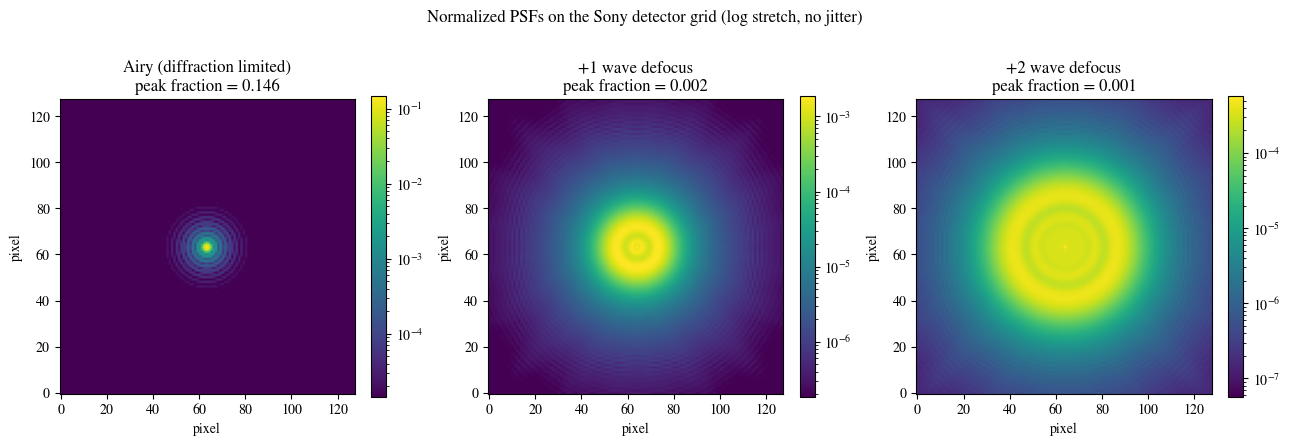

In [2]:
# Build an ImageSimulator to get a rendering context (plate scale, npix, jitter).
imsim = wcc_etc.ImageSimulator.from_sensor_and_scene('sony:r', scene, npix=300)

def render(psf, jitter=0.0, npix=128):
    ctx = imsim._context(jitter_sigma_mas=jitter)
    ctx.npix = npix
    return psf.render(ctx)

psfs = {
    'Airy (diffraction limited)': wcc_etc.AiryPSF(),
    '+1 wave defocus': wcc_etc.DefocusPSF(wcc_etc.DEFOCUS_1WAVE_PATH),
    '+2 wave defocus': wcc_etc.DefocusPSF(wcc_etc.DEFOCUS_2WAVE_PATH),
}

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
for ax, (name, psf) in zip(axes, psfs.items()):
    img = render(psf, jitter=0.0, npix=128)
    im = ax.imshow(img, origin='lower',
                   norm=LogNorm(vmin=img.max()*1e-4, vmax=img.max()), cmap='viridis')
    ax.set_title(f'{name}\npeak fraction = {img.max():.3f}')
    ax.set_xlabel('pixel'); ax.set_ylabel('pixel')
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle('Normalized PSFs on the Sony detector grid (log stretch, no jitter)', y=1.03)
fig.tight_layout(); plt.show()

## 2. Full image simulation

`ImageSimulator.simulate(time, psf=...)` distributes the source electrons over the PSF, adds the per-pixel sky background and dark current, then Poisson + Gaussian read noise. It returns a `SimulatedImage` with `image_clean` (noise-free), `image_e` (noisy electrons), a `saturation_mask`, and converters `to_adu()` / `to_fitsimg()`. Here: a G5V `r=15` star, 30 s, in-focus Airy PSF.

/Users/gudmundurstefansson/Dropbox/mypylib/notebooks/GIT/wcc-etc4/wcc-etc/src/wcc_etc/airy.py:195: UserWarning: n_pixels must be odd to center the PSF peak; using 301 instead of 300.
  warnings.warn(f"n_pixels must be odd to center the PSF peak; "


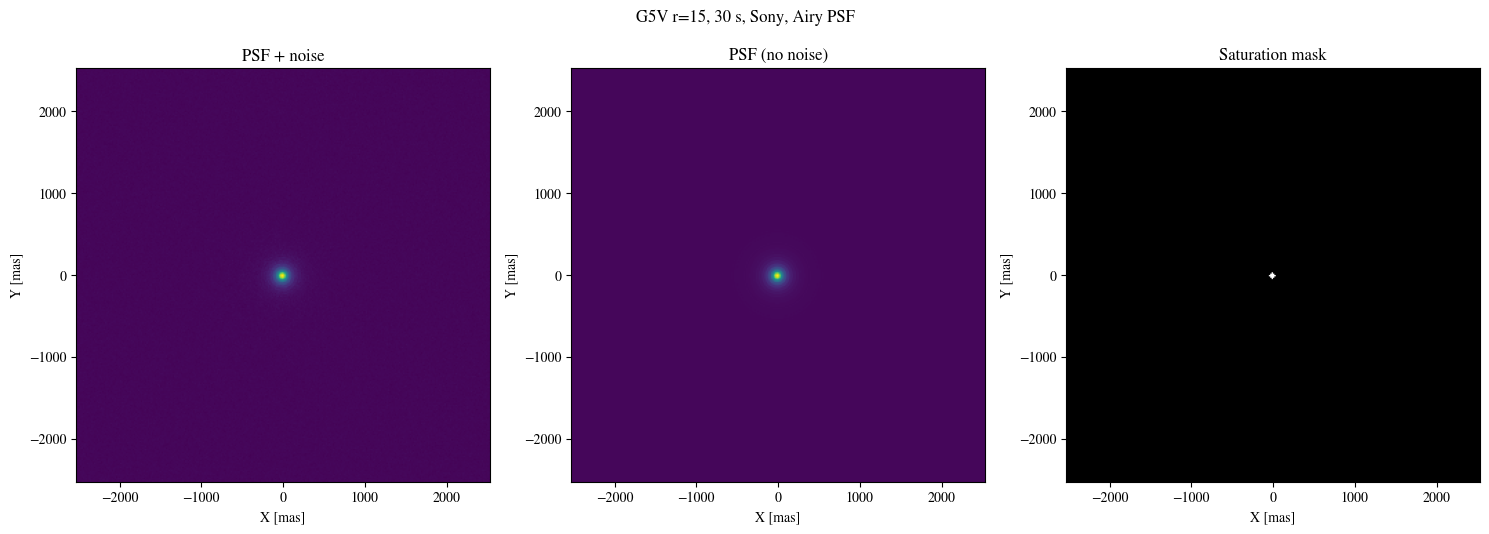

clean total electrons : 1.108e+06
peak pixel (e-)       : 116741.2
saturated pixels      : 13


In [3]:
res = imsim.simulate(time=30, psf=wcc_etc.AiryPSF(), add_noise=True, seed=0)

# SimulatedImage.plot_image_row gives the standard 3-panel view:
# PSF + noise, PSF (no noise), and the saturation mask, on a shared color scale.
fig, axes = res.plot_image_row(stretch='log', units='mas')
fig.suptitle('G5V r=15, 30 s, Sony, Airy PSF', y=1.02)
fig.tight_layout(); plt.show()

print(f'clean total electrons : {res.image_clean.sum():.3e}')
print(f'peak pixel (e-)       : {res.image_e.max():.1f}')
print(f'saturated pixels      : {res.saturation_mask.sum()}')

### Radial profile and encircled energy

The same `SimulatedImage` exposes convenience plots for the azimuthally-averaged radial profile and the encircled-energy (EE) curve. Both take `units='mas'` or `'pix'`; `plot_radial` marks the HWHM and `plot_encircled_energy` can mark a target EE fraction (here 80%).

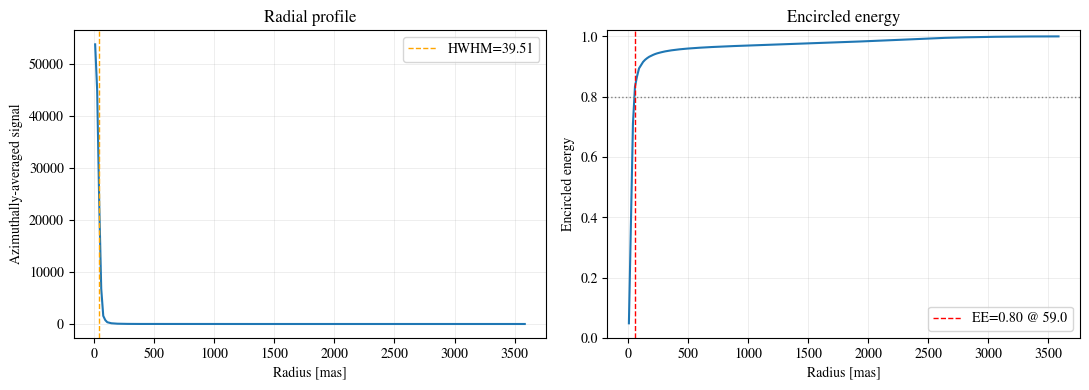

In [4]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4))
res.plot_radial(ax=axL, units='mas', title='Radial profile')
res.plot_encircled_energy(ax=axR, units='mas', ee_target=0.8, title='Encircled energy')
fig.tight_layout(); plt.show()

### Bokeh backend

Every plot has a bokeh variant via `backend='bokeh'`. In a notebook, call `output_notebook()` once and `show(...)` the returned figure. For the web portal you would instead pass `return_='components'` (script + div) or `return_='html'` to embed it.

In [5]:
from bokeh.io import output_notebook, show
output_notebook()
show(res.plot_image(backend='bokeh', units='mas', title='Airy PSF (bokeh)'))

Loading BokehJS ...

## 3. Effect of pointing jitter

Jitter is applied as a Gaussian blur of the PSF. More jitter -> broader PSF -> lower peak fraction and a more spread-out image.

/Users/gudmundurstefansson/Dropbox/mypylib/notebooks/GIT/wcc-etc4/wcc-etc/src/wcc_etc/airy.py:195: UserWarning: n_pixels must be odd to center the PSF peak; using 97 instead of 96.
  warnings.warn(f"n_pixels must be odd to center the PSF peak; "


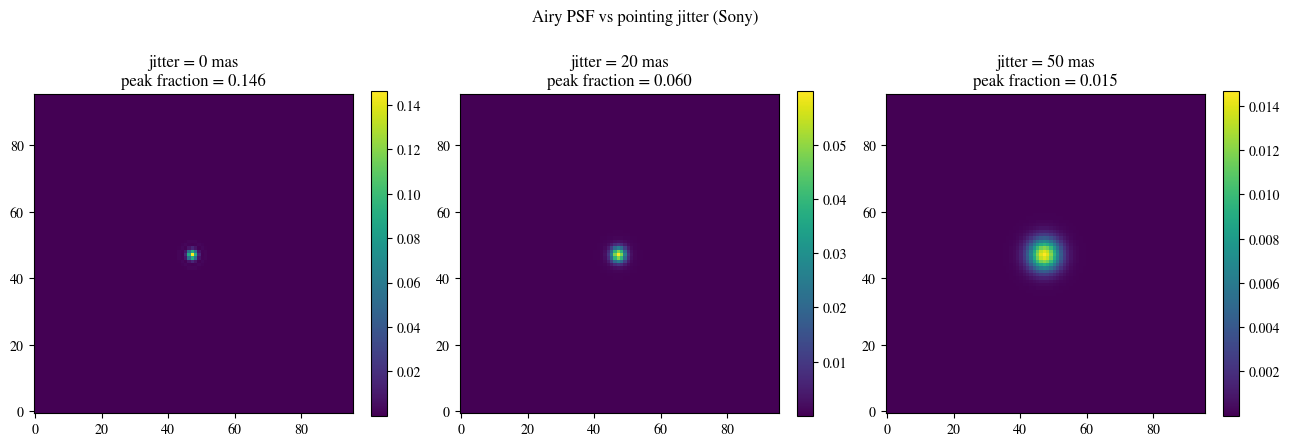

In [6]:
airy = wcc_etc.AiryPSF()
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
for ax, jit in zip(axes, [0.0, 20.0, 50.0]):
    img = render(airy, jitter=jit, npix=96)
    im = ax.imshow(img, origin='lower', cmap='viridis')
    ax.set_title(f'jitter = {jit:.0f} mas\npeak fraction = {img.max():.3f}')
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle('Airy PSF vs pointing jitter (Sony)', y=1.03)
fig.tight_layout(); plt.show()

## 4. PSF-aware SNR cross-check (Airy vs analytic)

With the default aperture and the diffraction-limited Airy PSF, the rendered-PSF `get_image_snr` should reproduce the analytic ETC `get_snr` (the small residual is 2-D pixelation vs the 1-D Airy curve). We assert they agree to within ~3%.

In [7]:
sim.update(source__mag=15)
etc_snr = float(sim.get_snr(60).value)
img_snr = sim.get_image_snr(time=60)['snr']
diff_pct = 100.0 * (img_snr - etc_snr) / etc_snr

print(f'get_snr (analytic Airy)     : {etc_snr:.3f}')
print(f'get_image_snr (rendered Airy): {img_snr:.3f}')
print(f'difference                  : {diff_pct:+.2f} %')

assert abs(diff_pct) < 3.0, f'cross-check off by {diff_pct:.2f}%'
print('OK: agree within 3%')

get_snr (analytic Airy)     : 1391.769
get_image_snr (rendered Airy): 1380.404
difference                  : -0.82 %
OK: agree within 3%


/Users/gudmundurstefansson/Dropbox/mypylib/notebooks/GIT/wcc-etc4/wcc-etc/src/wcc_etc/airy.py:195: UserWarning: n_pixels must be odd to center the PSF peak; using 129 instead of 128.
  warnings.warn(f"n_pixels must be odd to center the PSF peak; "


## 5. Defocus SNR penalty (same aperture)

At a fixed aperture, a defocused PSF spreads the same light over more noise pixels and loses less of it inside the aperture only at large radii — at the default aperture the enclosed fraction drops, so the SNR drops. Comparing the +2 wave defocus to the in-focus Airy at the same default aperture quantifies the penalty.

In [8]:
defocus2 = wcc_etc.DefocusPSF(wcc_etc.DEFOCUS_2WAVE_PATH)

airy_res = sim.get_image_snr(time=60, psf=wcc_etc.AiryPSF())
def2_res = sim.get_image_snr(time=60, psf=defocus2)
drop_pct = 100.0 * (def2_res['snr'] - airy_res['snr']) / airy_res['snr']

print(f"aperture radius (mas)       : {airy_res['r_aper_mas']:.1f} (same for both)")
print()
for label, r in [('in-focus Airy', airy_res), ('+2 wave defocus', def2_res)]:
    print(f"{label:16s}: SNR = {r['snr']:6.2f}  enclosed = {r['enclosed_fraction']:.3f}  "
          f"n_pix = {r['n_pix']}")
print()
print(f'SNR drop from defocus       : {drop_pct:+.1f} %')

/Users/gudmundurstefansson/Dropbox/mypylib/notebooks/GIT/wcc-etc4/wcc-etc/src/wcc_etc/airy.py:195: UserWarning: n_pixels must be odd to center the PSF peak; using 129 instead of 128.
  warnings.warn(f"n_pixels must be odd to center the PSF peak; "


aperture radius (mas)       : 64.2 (same for both)

in-focus Airy   : SNR = 1380.40  enclosed = 0.886  n_pix = 52
+2 wave defocus : SNR = 196.09  enclosed = 0.018  n_pix = 52

SNR drop from defocus       : -85.8 %


## 6. Aperture optimization

`optimize=True` finds the SNR-maximizing aperture radius. For the compact Airy the optimum is small; for the spread-out defocus PSF it moves outward (and recovers some, but not all, of the lost SNR). We compare the optimized result to the default-aperture result for each PSF.

In [9]:
for name, psf in [('in-focus Airy', wcc_etc.AiryPSF()), ('+2 wave defocus', defocus2)]:
    default = sim.get_image_snr(time=60, psf=psf)
    opt = sim.get_image_snr(time=60, psf=psf, optimize=True)
    print(f'{name}:')
    print(f"  default aperture : r = {default['r_aper_mas']:6.1f} mas  "
          f"SNR = {default['snr']:6.2f}  n_pix = {default['n_pix']}")
    print(f"  optimized        : r = {opt['r_aper_mas']:6.1f} mas  "
          f"SNR = {opt['snr']:6.2f}  n_pix = {opt['n_pix']}  "
          f"enclosed = {opt['enclosed_fraction']:.3f}")
    gain = 100.0 * (opt['snr'] - default['snr']) / default['snr']
    print(f'  SNR gain from optimizing aperture: {gain:+.1f} %')
    print()

/Users/gudmundurstefansson/Dropbox/mypylib/notebooks/GIT/wcc-etc4/wcc-etc/src/wcc_etc/airy.py:195: UserWarning: n_pixels must be odd to center the PSF peak; using 129 instead of 128.
  warnings.warn(f"n_pixels must be odd to center the PSF peak; "
/Users/gudmundurstefansson/Dropbox/mypylib/notebooks/GIT/wcc-etc4/wcc-etc/src/wcc_etc/airy.py:195: UserWarning: n_pixels must be odd to center the PSF peak; using 129 instead of 128.
  warnings.warn(f"n_pixels must be odd to center the PSF peak; "


in-focus Airy:
  default aperture : r =   64.2 mas  SNR = 1380.40  n_pix = 52
  optimized        : r =  420.2 mas  SNR = 1451.67  n_pix = 1959  enclosed = 0.988
  SNR gain from optimizing aperture: +5.2 %



+2 wave defocus:
  default aperture : r =   64.2 mas  SNR = 196.09  n_pix = 52
  optimized        : r =  765.7 mas  SNR = 1437.12  n_pix = 6464  enclosed = 0.989
  SNR gain from optimizing aperture: +632.9 %



SNR as a function of aperture radius for each PSF (r=15, 60 s); the marker shows the `optimize=True` choice — small for the compact Airy, larger for the defocus PSF.

/Users/gudmundurstefansson/Dropbox/mypylib/notebooks/GIT/wcc-etc4/wcc-etc/src/wcc_etc/airy.py:195: UserWarning: n_pixels must be odd to center the PSF peak; using 129 instead of 128.
  warnings.warn(f"n_pixels must be odd to center the PSF peak; "
/Users/gudmundurstefansson/Dropbox/mypylib/notebooks/GIT/wcc-etc4/wcc-etc/src/wcc_etc/airy.py:195: UserWarning: n_pixels must be odd to center the PSF peak; using 129 instead of 128.
  warnings.warn(f"n_pixels must be odd to center the PSF peak; "
/Users/gudmundurstefansson/Dropbox/mypylib/notebooks/GIT/wcc-etc4/wcc-etc/src/wcc_etc/airy.py:195: UserWarning: n_pixels must be odd to center the PSF peak; using 129 instead of 128.
  warnings.warn(f"n_pixels must be odd to center the PSF peak; "


/Users/gudmundurstefansson/Dropbox/mypylib/notebooks/GIT/wcc-etc4/wcc-etc/src/wcc_etc/airy.py:195: UserWarning: n_pixels must be odd to center the PSF peak; using 129 instead of 128.
  warnings.warn(f"n_pixels must be odd to center the PSF peak; "
/Users/gudmundurstefansson/Dropbox/mypylib/notebooks/GIT/wcc-etc4/wcc-etc/src/wcc_etc/airy.py:195: UserWarning: n_pixels must be odd to center the PSF peak; using 129 instead of 128.
  warnings.warn(f"n_pixels must be odd to center the PSF peak; "
/Users/gudmundurstefansson/Dropbox/mypylib/notebooks/GIT/wcc-etc4/wcc-etc/src/wcc_etc/airy.py:195: UserWarning: n_pixels must be odd to center the PSF peak; using 129 instead of 128.
  warnings.warn(f"n_pixels must be odd to center the PSF peak; "


/Users/gudmundurstefansson/Dropbox/mypylib/notebooks/GIT/wcc-etc4/wcc-etc/src/wcc_etc/airy.py:195: UserWarning: n_pixels must be odd to center the PSF peak; using 129 instead of 128.
  warnings.warn(f"n_pixels must be odd to center the PSF peak; "
/Users/gudmundurstefansson/Dropbox/mypylib/notebooks/GIT/wcc-etc4/wcc-etc/src/wcc_etc/airy.py:195: UserWarning: n_pixels must be odd to center the PSF peak; using 129 instead of 128.
  warnings.warn(f"n_pixels must be odd to center the PSF peak; "
/Users/gudmundurstefansson/Dropbox/mypylib/notebooks/GIT/wcc-etc4/wcc-etc/src/wcc_etc/airy.py:195: UserWarning: n_pixels must be odd to center the PSF peak; using 129 instead of 128.
  warnings.warn(f"n_pixels must be odd to center the PSF peak; "


/Users/gudmundurstefansson/Dropbox/mypylib/notebooks/GIT/wcc-etc4/wcc-etc/src/wcc_etc/airy.py:195: UserWarning: n_pixels must be odd to center the PSF peak; using 129 instead of 128.
  warnings.warn(f"n_pixels must be odd to center the PSF peak; "
/Users/gudmundurstefansson/Dropbox/mypylib/notebooks/GIT/wcc-etc4/wcc-etc/src/wcc_etc/airy.py:195: UserWarning: n_pixels must be odd to center the PSF peak; using 129 instead of 128.
  warnings.warn(f"n_pixels must be odd to center the PSF peak; "
/Users/gudmundurstefansson/Dropbox/mypylib/notebooks/GIT/wcc-etc4/wcc-etc/src/wcc_etc/airy.py:195: UserWarning: n_pixels must be odd to center the PSF peak; using 129 instead of 128.
  warnings.warn(f"n_pixels must be odd to center the PSF peak; "


/Users/gudmundurstefansson/Dropbox/mypylib/notebooks/GIT/wcc-etc4/wcc-etc/src/wcc_etc/airy.py:195: UserWarning: n_pixels must be odd to center the PSF peak; using 129 instead of 128.
  warnings.warn(f"n_pixels must be odd to center the PSF peak; "
/Users/gudmundurstefansson/Dropbox/mypylib/notebooks/GIT/wcc-etc4/wcc-etc/src/wcc_etc/airy.py:195: UserWarning: n_pixels must be odd to center the PSF peak; using 129 instead of 128.
  warnings.warn(f"n_pixels must be odd to center the PSF peak; "
/Users/gudmundurstefansson/Dropbox/mypylib/notebooks/GIT/wcc-etc4/wcc-etc/src/wcc_etc/airy.py:195: UserWarning: n_pixels must be odd to center the PSF peak; using 129 instead of 128.
  warnings.warn(f"n_pixels must be odd to center the PSF peak; "


/Users/gudmundurstefansson/Dropbox/mypylib/notebooks/GIT/wcc-etc4/wcc-etc/src/wcc_etc/airy.py:195: UserWarning: n_pixels must be odd to center the PSF peak; using 129 instead of 128.
  warnings.warn(f"n_pixels must be odd to center the PSF peak; "
/Users/gudmundurstefansson/Dropbox/mypylib/notebooks/GIT/wcc-etc4/wcc-etc/src/wcc_etc/airy.py:195: UserWarning: n_pixels must be odd to center the PSF peak; using 129 instead of 128.
  warnings.warn(f"n_pixels must be odd to center the PSF peak; "
/Users/gudmundurstefansson/Dropbox/mypylib/notebooks/GIT/wcc-etc4/wcc-etc/src/wcc_etc/airy.py:195: UserWarning: n_pixels must be odd to center the PSF peak; using 129 instead of 128.
  warnings.warn(f"n_pixels must be odd to center the PSF peak; "


/Users/gudmundurstefansson/Dropbox/mypylib/notebooks/GIT/wcc-etc4/wcc-etc/src/wcc_etc/airy.py:195: UserWarning: n_pixels must be odd to center the PSF peak; using 129 instead of 128.
  warnings.warn(f"n_pixels must be odd to center the PSF peak; "
/Users/gudmundurstefansson/Dropbox/mypylib/notebooks/GIT/wcc-etc4/wcc-etc/src/wcc_etc/airy.py:195: UserWarning: n_pixels must be odd to center the PSF peak; using 129 instead of 128.
  warnings.warn(f"n_pixels must be odd to center the PSF peak; "
/Users/gudmundurstefansson/Dropbox/mypylib/notebooks/GIT/wcc-etc4/wcc-etc/src/wcc_etc/airy.py:195: UserWarning: n_pixels must be odd to center the PSF peak; using 129 instead of 128.
  warnings.warn(f"n_pixels must be odd to center the PSF peak; "


/Users/gudmundurstefansson/Dropbox/mypylib/notebooks/GIT/wcc-etc4/wcc-etc/src/wcc_etc/airy.py:195: UserWarning: n_pixels must be odd to center the PSF peak; using 129 instead of 128.
  warnings.warn(f"n_pixels must be odd to center the PSF peak; "
/Users/gudmundurstefansson/Dropbox/mypylib/notebooks/GIT/wcc-etc4/wcc-etc/src/wcc_etc/airy.py:195: UserWarning: n_pixels must be odd to center the PSF peak; using 129 instead of 128.
  warnings.warn(f"n_pixels must be odd to center the PSF peak; "
/Users/gudmundurstefansson/Dropbox/mypylib/notebooks/GIT/wcc-etc4/wcc-etc/src/wcc_etc/airy.py:195: UserWarning: n_pixels must be odd to center the PSF peak; using 129 instead of 128.
  warnings.warn(f"n_pixels must be odd to center the PSF peak; "


/Users/gudmundurstefansson/Dropbox/mypylib/notebooks/GIT/wcc-etc4/wcc-etc/src/wcc_etc/airy.py:195: UserWarning: n_pixels must be odd to center the PSF peak; using 129 instead of 128.
  warnings.warn(f"n_pixels must be odd to center the PSF peak; "
/Users/gudmundurstefansson/Dropbox/mypylib/notebooks/GIT/wcc-etc4/wcc-etc/src/wcc_etc/airy.py:195: UserWarning: n_pixels must be odd to center the PSF peak; using 129 instead of 128.
  warnings.warn(f"n_pixels must be odd to center the PSF peak; "
/Users/gudmundurstefansson/Dropbox/mypylib/notebooks/GIT/wcc-etc4/wcc-etc/src/wcc_etc/airy.py:195: UserWarning: n_pixels must be odd to center the PSF peak; using 129 instead of 128.
  warnings.warn(f"n_pixels must be odd to center the PSF peak; "


/Users/gudmundurstefansson/Dropbox/mypylib/notebooks/GIT/wcc-etc4/wcc-etc/src/wcc_etc/airy.py:195: UserWarning: n_pixels must be odd to center the PSF peak; using 129 instead of 128.
  warnings.warn(f"n_pixels must be odd to center the PSF peak; "
/Users/gudmundurstefansson/Dropbox/mypylib/notebooks/GIT/wcc-etc4/wcc-etc/src/wcc_etc/airy.py:195: UserWarning: n_pixels must be odd to center the PSF peak; using 129 instead of 128.
  warnings.warn(f"n_pixels must be odd to center the PSF peak; "
/Users/gudmundurstefansson/Dropbox/mypylib/notebooks/GIT/wcc-etc4/wcc-etc/src/wcc_etc/airy.py:195: UserWarning: n_pixels must be odd to center the PSF peak; using 129 instead of 128.
  warnings.warn(f"n_pixels must be odd to center the PSF peak; "


/Users/gudmundurstefansson/Dropbox/mypylib/notebooks/GIT/wcc-etc4/wcc-etc/src/wcc_etc/airy.py:195: UserWarning: n_pixels must be odd to center the PSF peak; using 129 instead of 128.
  warnings.warn(f"n_pixels must be odd to center the PSF peak; "
/Users/gudmundurstefansson/Dropbox/mypylib/notebooks/GIT/wcc-etc4/wcc-etc/src/wcc_etc/airy.py:195: UserWarning: n_pixels must be odd to center the PSF peak; using 129 instead of 128.
  warnings.warn(f"n_pixels must be odd to center the PSF peak; "
/Users/gudmundurstefansson/Dropbox/mypylib/notebooks/GIT/wcc-etc4/wcc-etc/src/wcc_etc/airy.py:195: UserWarning: n_pixels must be odd to center the PSF peak; using 129 instead of 128.
  warnings.warn(f"n_pixels must be odd to center the PSF peak; "


/Users/gudmundurstefansson/Dropbox/mypylib/notebooks/GIT/wcc-etc4/wcc-etc/src/wcc_etc/airy.py:195: UserWarning: n_pixels must be odd to center the PSF peak; using 129 instead of 128.
  warnings.warn(f"n_pixels must be odd to center the PSF peak; "
/Users/gudmundurstefansson/Dropbox/mypylib/notebooks/GIT/wcc-etc4/wcc-etc/src/wcc_etc/airy.py:195: UserWarning: n_pixels must be odd to center the PSF peak; using 129 instead of 128.
  warnings.warn(f"n_pixels must be odd to center the PSF peak; "
/Users/gudmundurstefansson/Dropbox/mypylib/notebooks/GIT/wcc-etc4/wcc-etc/src/wcc_etc/airy.py:195: UserWarning: n_pixels must be odd to center the PSF peak; using 129 instead of 128.
  warnings.warn(f"n_pixels must be odd to center the PSF peak; "


/Users/gudmundurstefansson/Dropbox/mypylib/notebooks/GIT/wcc-etc4/wcc-etc/src/wcc_etc/airy.py:195: UserWarning: n_pixels must be odd to center the PSF peak; using 129 instead of 128.
  warnings.warn(f"n_pixels must be odd to center the PSF peak; "
/Users/gudmundurstefansson/Dropbox/mypylib/notebooks/GIT/wcc-etc4/wcc-etc/src/wcc_etc/airy.py:195: UserWarning: n_pixels must be odd to center the PSF peak; using 129 instead of 128.
  warnings.warn(f"n_pixels must be odd to center the PSF peak; "
/Users/gudmundurstefansson/Dropbox/mypylib/notebooks/GIT/wcc-etc4/wcc-etc/src/wcc_etc/airy.py:195: UserWarning: n_pixels must be odd to center the PSF peak; using 129 instead of 128.
  warnings.warn(f"n_pixels must be odd to center the PSF peak; "


/Users/gudmundurstefansson/Dropbox/mypylib/notebooks/GIT/wcc-etc4/wcc-etc/src/wcc_etc/airy.py:195: UserWarning: n_pixels must be odd to center the PSF peak; using 129 instead of 128.
  warnings.warn(f"n_pixels must be odd to center the PSF peak; "
/Users/gudmundurstefansson/Dropbox/mypylib/notebooks/GIT/wcc-etc4/wcc-etc/src/wcc_etc/airy.py:195: UserWarning: n_pixels must be odd to center the PSF peak; using 129 instead of 128.
  warnings.warn(f"n_pixels must be odd to center the PSF peak; "
/Users/gudmundurstefansson/Dropbox/mypylib/notebooks/GIT/wcc-etc4/wcc-etc/src/wcc_etc/airy.py:195: UserWarning: n_pixels must be odd to center the PSF peak; using 129 instead of 128.
  warnings.warn(f"n_pixels must be odd to center the PSF peak; "


/Users/gudmundurstefansson/Dropbox/mypylib/notebooks/GIT/wcc-etc4/wcc-etc/src/wcc_etc/airy.py:195: UserWarning: n_pixels must be odd to center the PSF peak; using 129 instead of 128.
  warnings.warn(f"n_pixels must be odd to center the PSF peak; "
/Users/gudmundurstefansson/Dropbox/mypylib/notebooks/GIT/wcc-etc4/wcc-etc/src/wcc_etc/airy.py:195: UserWarning: n_pixels must be odd to center the PSF peak; using 129 instead of 128.
  warnings.warn(f"n_pixels must be odd to center the PSF peak; "
/Users/gudmundurstefansson/Dropbox/mypylib/notebooks/GIT/wcc-etc4/wcc-etc/src/wcc_etc/airy.py:195: UserWarning: n_pixels must be odd to center the PSF peak; using 129 instead of 128.
  warnings.warn(f"n_pixels must be odd to center the PSF peak; "


/Users/gudmundurstefansson/Dropbox/mypylib/notebooks/GIT/wcc-etc4/wcc-etc/src/wcc_etc/airy.py:195: UserWarning: n_pixels must be odd to center the PSF peak; using 129 instead of 128.
  warnings.warn(f"n_pixels must be odd to center the PSF peak; "
/Users/gudmundurstefansson/Dropbox/mypylib/notebooks/GIT/wcc-etc4/wcc-etc/src/wcc_etc/airy.py:195: UserWarning: n_pixels must be odd to center the PSF peak; using 129 instead of 128.
  warnings.warn(f"n_pixels must be odd to center the PSF peak; "
/Users/gudmundurstefansson/Dropbox/mypylib/notebooks/GIT/wcc-etc4/wcc-etc/src/wcc_etc/airy.py:195: UserWarning: n_pixels must be odd to center the PSF peak; using 129 instead of 128.
  warnings.warn(f"n_pixels must be odd to center the PSF peak; "


/Users/gudmundurstefansson/Dropbox/mypylib/notebooks/GIT/wcc-etc4/wcc-etc/src/wcc_etc/airy.py:195: UserWarning: n_pixels must be odd to center the PSF peak; using 129 instead of 128.
  warnings.warn(f"n_pixels must be odd to center the PSF peak; "
/Users/gudmundurstefansson/Dropbox/mypylib/notebooks/GIT/wcc-etc4/wcc-etc/src/wcc_etc/airy.py:195: UserWarning: n_pixels must be odd to center the PSF peak; using 129 instead of 128.
  warnings.warn(f"n_pixels must be odd to center the PSF peak; "
/Users/gudmundurstefansson/Dropbox/mypylib/notebooks/GIT/wcc-etc4/wcc-etc/src/wcc_etc/airy.py:195: UserWarning: n_pixels must be odd to center the PSF peak; using 129 instead of 128.
  warnings.warn(f"n_pixels must be odd to center the PSF peak; "


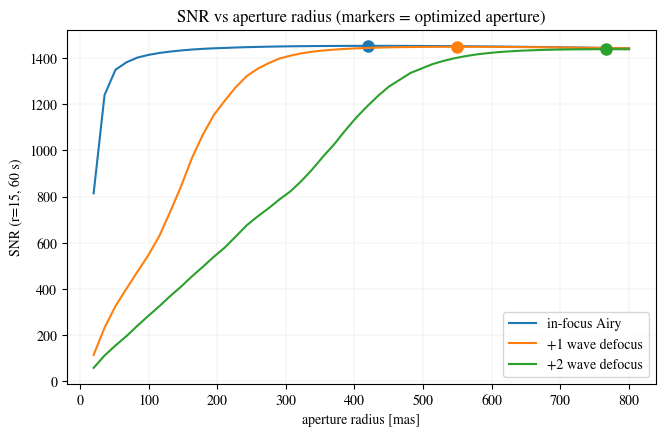

In [10]:
radii = np.linspace(20, 800, 50)
psfs_opt = {'in-focus Airy': wcc_etc.AiryPSF(),
            '+1 wave defocus': wcc_etc.DefocusPSF(wcc_etc.DEFOCUS_1WAVE_PATH),
            '+2 wave defocus': defocus2}

fig, ax = plt.subplots(figsize=(7.6, 4.6))
for name, psf in psfs_opt.items():
    snr = [sim.get_image_snr(time=60, psf=psf, r_aper_mas=r)['snr'] for r in radii]
    line, = ax.plot(radii, snr, label=name)
    opt = sim.get_image_snr(time=60, psf=psf, optimize=True)
    ax.plot(opt['r_aper_mas'], opt['snr'], 'o', color=line.get_color(), ms=8)
ax.set_xlabel('aperture radius [mas]'); ax.set_ylabel('SNR (r=15, 60 s)')
ax.set_title('SNR vs aperture radius (markers = optimized aperture)')
ax.legend(); ax.grid(lw=0.3, alpha=0.4); plt.show()

## Summary

- `AiryPSF`, `DefocusPSF`, `CustomPSF` render normalized PSFs onto the detector grid (pixel-size aware, jitter aware).
- `ImageSimulator.from_sensor_and_scene(...).simulate(time, psf=...)` produces a realistic noisy electron image driven by source magnitude, with a saturation mask; `to_adu()` / `to_fitsimg()` bridge to ADU and the photometry tools.
- `Simulation.get_image_snr` computes an aperture SNR from a rendered PSF. For the in-focus Airy case it reproduces the analytic `get_snr` (cross-check within a few percent); for defocus it quantifies the SNR penalty and `optimize=True` finds the SNR-maximizing aperture.
- `get_snr` itself (the analytic path) is unchanged.